In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
ret = pd.read_csv("../data/processed/dax_log_returns.csv", index_col=0, parse_dates=True).squeeze()

sigma_gjr = pd.read_csv("../results/tables/gjr_sigma_forecasts.csv", index_col=0, parse_dates=True).squeeze()
sigma_garch = pd.read_csv("../results/tables/garch11_sigma_forecasts.csv", index_col=0, parse_dates=True).squeeze()

# Align returns with forecast dates forecast
ret_test = ret.reindex(sigma_gjr.index)

ret_test.head(), sigma_gjr.head()

(2023-09-15    0.556743
 2023-09-18   -1.052551
 2023-09-19   -0.399086
 2023-09-20    0.744830
 2023-09-21   -1.337860
 Name: ^GDAXI, dtype: float64,
 2023-09-15    0.769048
 2023-09-18    0.755153
 2023-09-19    0.902829
 2023-09-20    0.886071
 2023-09-21    0.854952
 Name: sigma_gjr, dtype: float64)

In [3]:
alpha_1 = 0.01
alpha_5 = 0.05

z1 = norm.ppf(alpha_1)
z5 = norm.ppf(alpha_5)

var_gjr_1 = z1 * sigma_gjr
var_gjr_5 = z5 * sigma_gjr

var_garch_1 = z1 * sigma_garch
var_garch_5 = z5 * sigma_garch

var_df = pd.DataFrame({
    "ret": ret_test,
    "VaR_GJR_1%": var_gjr_1,
    "VaR_GJR_5%": var_gjr_5,
    "VaR_GARCH_1%": var_garch_1,
    "VaR_GARCH_5%": var_garch_5,
})

var_df.head()

,ret,VaR_GJR_1%,VaR_GJR_5%,VaR_GARCH_1%,VaR_GARCH_5%
2023-09-15,0.556743,-1.789074,-1.264972,-1.863752,-1.317773
2023-09-18,-1.052551,-1.756749,-1.242117,-1.863100,-1.317312
2023-09-19,-0.399086,-2.100295,-1.485022,-2.012731,-1.423110
2023-09-20,0.744830,-2.061308,-1.457456,-1.957584,-1.384117
2023-09-21,-1.337860,-1.988915,-1.406270,-1.984587,-1.403210


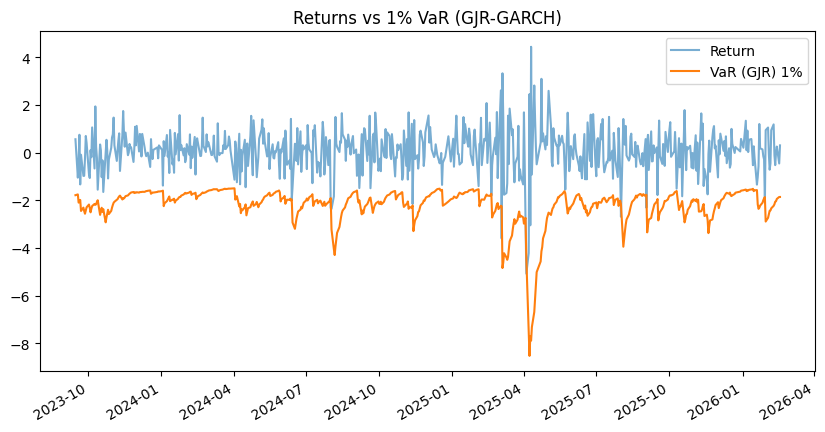

In [4]:
plt.figure(figsize=(10,5))
var_df["ret"].plot(label="Return", alpha=0.6)
var_df["VaR_GJR_1%"].plot(label="VaR (GJR) 1%")
plt.legend()
plt.title("Returns vs 1% VaR (GJR-GARCH)")
plt.show()

In [5]:
var_df.to_csv("../results/tables/var_series.csv")
print("Saved: results/tables/var_series.csv")

Saved: results/tables/var_series.csv


In [6]:
var_df = pd.read_csv("../results/tables/var_series.csv", index_col=0, parse_dates=True)
var_df.head()

,ret,VaR_GJR_1%,VaR_GJR_5%,VaR_GARCH_1%,VaR_GARCH_5%
2023-09-15,0.556743,-1.789074,-1.264972,-1.863752,-1.317773
2023-09-18,-1.052551,-1.756749,-1.242117,-1.863100,-1.317312
2023-09-19,-0.399086,-2.100295,-1.485022,-2.012731,-1.423110
2023-09-20,0.744830,-2.061308,-1.457456,-1.957584,-1.384117
2023-09-21,-1.337860,-1.988915,-1.406270,-1.984587,-1.403210


In [7]:
def violations(returns, var_series):
    v = (returns < var_series).astype(int)
    return v

v_gjr_1 = violations(var_df["ret"], var_df["VaR_GJR_1%"])
v_gjr_5 = violations(var_df["ret"], var_df["VaR_GJR_5%"])

print("GJR 1% violations:", v_gjr_1.sum(), "out of", len(v_gjr_1))
print("GJR 5% violations:", v_gjr_5.sum(), "out of", len(v_gjr_5))

GJR 1% violations: 9 out of 614
GJR 5% violations: 24 out of 614


In [8]:
from scipy.stats import chi2

def kupiec_pof_test(violations, alpha):
    T = len(violations)
    x = int(np.sum(violations))
    pi_hat = x / T

    eps = 1e-12
    pi_hat = min(max(pi_hat, eps), 1 - eps)
    alpha = min(max(alpha, eps), 1 - eps)

    ll_null = (T - x) * np.log(1 - alpha) + x * np.log(alpha)
    ll_alt  = (T - x) * np.log(1 - pi_hat) + x * np.log(pi_hat)

    LR_pof = -2 * (ll_null - ll_alt)
    p_value = 1 - chi2.cdf(LR_pof, df=1)
    return LR_pof, p_value, x, T, pi_hat

kup_1 = kupiec_pof_test(v_gjr_1, 0.01)
kup_5 = kupiec_pof_test(v_gjr_5, 0.05)

print("Kupiec 1%:", kup_1)
print("Kupiec 5%:", kup_5)

Kupiec 1%: (np.float64(1.1766745752015595), np.float64(0.2780340271610843), 9, 614, 0.014657980456026058)
Kupiec 5%: (np.float64(1.658642141634516), np.float64(0.19778675892435704), 24, 614, 0.03908794788273615)


In [9]:
def christoffersen_independence_test(violations):
    v = np.asarray(violations).astype(int)

    n00 = n01 = n10 = n11 = 0
    for t in range(1, len(v)):
        if v[t-1] == 0 and v[t] == 0: n00 += 1
        if v[t-1] == 0 and v[t] == 1: n01 += 1
        if v[t-1] == 1 and v[t] == 0: n10 += 1
        if v[t-1] == 1 and v[t] == 1: n11 += 1

    eps = 1e-12
    p01 = n01 / max(n00 + n01, 1)
    p11 = n11 / max(n10 + n11, 1)
    p  = (n01 + n11) / max(n00 + n01 + n10 + n11, 1)

    # clamp
    p01 = min(max(p01, eps), 1 - eps)
    p11 = min(max(p11, eps), 1 - eps)
    p   = min(max(p, eps), 1 - eps)

    ll_ind = (n00 + n10) * np.log(1 - p) + (n01 + n11) * np.log(p)
    ll_dep = n00 * np.log(1 - p01) + n01 * np.log(p01) + n10 * np.log(1 - p11) + n11 * np.log(p11)

    LR_ind = -2 * (ll_ind - ll_dep)
    p_value = 1 - chi2.cdf(LR_ind, df=1)

    counts = {"n00": n00, "n01": n01, "n10": n10, "n11": n11}
    return LR_ind, p_value, counts

def conditional_coverage_test(LR_pof, LR_ind):
    LR_cc = LR_pof + LR_ind
    p_value = 1 - chi2.cdf(LR_cc, df=2)
    return LR_cc, p_value

# 1%
LRind_1, pind_1, counts_1 = christoffersen_independence_test(v_gjr_1)
LRpof_1, ppof_1, x1, T1, pihat1 = kupiec_pof_test(v_gjr_1, 0.01)
LRcc_1, pcc_1 = conditional_coverage_test(LRpof_1, LRind_1)

# 5%
LRind_5, pind_5, counts_5 = christoffersen_independence_test(v_gjr_5)
LRpof_5, ppof_5, x5, T5, pihat5 = kupiec_pof_test(v_gjr_5, 0.05)
LRcc_5, pcc_5 = conditional_coverage_test(LRpof_5, LRind_5)

print("Independence 1%:", LRind_1, pind_1, counts_1)
print("CC 1%:", LRcc_1, pcc_1)
print("Independence 5%:", LRind_5, pind_5, counts_5)
print("CC 5%:", LRcc_5, pcc_5)

Independence 1%: 2.4890689388301155 0.11463952519736409 {'n00': 596, 'n01': 8, 'n10': 8, 'n11': 1}
CC 1%: 3.665743514031675 0.15995355981815784
Independence 5%: 1.00193010629647 0.316843928917508 {'n00': 567, 'n01': 22, 'n10': 22, 'n11': 2}
CC 5%: 2.660572247930986 0.26440159884197545


In [10]:
backtest_results = pd.DataFrame({
    "alpha": [0.01, 0.05],
    "violations": [x1, x5],
    "T": [T1, T5],
    "pi_hat": [pihat1, pihat5],
    "Kupiec_LR": [LRpof_1, LRpof_5],
    "Kupiec_p": [ppof_1, ppof_5],
    "Ind_LR": [LRind_1, LRind_5],
    "Ind_p": [pind_1, pind_5],
    "CC_LR": [LRcc_1, LRcc_5],
    "CC_p": [pcc_1, pcc_5],
})

backtest_results

,alpha,violations,T,pi_hat,Kupiec_LR,Kupiec_p,Ind_LR,Ind_p,CC_LR,CC_p
0,0.01,9,614,0.014658,1.176675,0.278034,2.489069,0.114640,3.665744,0.159954
1,0.05,24,614,0.039088,1.658642,0.197787,1.001930,0.316844,2.660572,0.264402


In [11]:
backtest_results.to_csv("../results/tables/var_backtest_results_gjr.csv", index=False)
print("Saved: results/tables/var_backtest_results_gjr.csv")

Saved: results/tables/var_backtest_results_gjr.csv


In [12]:
v_garch_1 = violations(var_df["ret"], var_df["VaR_GARCH_1%"])
v_garch_5 = violations(var_df["ret"], var_df["VaR_GARCH_5%"])

In [13]:
# 1%
LRind_g1, pind_g1, _ = christoffersen_independence_test(v_garch_1)
LRpof_g1, ppof_g1, xg1, Tg1, pihatg1 = kupiec_pof_test(v_garch_1, 0.01)
LRcc_g1, pcc_g1 = conditional_coverage_test(LRpof_g1, LRind_g1)

# 5%
LRind_g5, pind_g5, _ = christoffersen_independence_test(v_garch_5)
LRpof_g5, ppof_g5, xg5, Tg5, pihatg5 = kupiec_pof_test(v_garch_5, 0.05)
LRcc_g5, pcc_g5 = conditional_coverage_test(LRpof_g5, LRind_g5)

In [14]:
compare_bt = pd.DataFrame({
    "model": ["GJR-GARCH", "GJR-GARCH", "GARCH", "GARCH"],
    "alpha": [0.01, 0.05, 0.01, 0.05],
    "violations": [x1, x5, xg1, xg5],
    "T": [T1, T5, Tg1, Tg5],
    "pi_hat": [pihat1, pihat5, pihatg1, pihatg5],
    "Kupiec_p": [ppof_1, ppof_5, ppof_g1, ppof_g5],
    "Ind_p": [pind_1, pind_5, pind_g1, pind_g5],
    "CC_p": [pcc_1, pcc_5, pcc_g1, pcc_g5],
})

compare_bt

,model,alpha,violations,T,pi_hat,Kupiec_p,Ind_p,CC_p
0,GJR-GARCH,0.01,9,614,0.014658,0.278034,0.114640,0.159954
1,GJR-GARCH,0.05,24,614,0.039088,0.197787,0.316844,0.264402
2,GARCH,0.01,7,614,0.011401,0.732958,0.062467,0.166371
3,GARCH,0.05,24,614,0.039088,0.197787,0.072228,0.086714


In [15]:
compare_bt.to_csv("../results/tables/var_backtest_comparison.csv", index=False)
print("Saved: results/tables/var_backtest_comparison.csv")

Saved: results/tables/var_backtest_comparison.csv
